# Proyecto Final de Ciencia de Datos  
## Predicción de abandono de clientes (Customer Churn)

**Objetivo del notebook:**  
Construir un proyecto completo de ciencia de datos que pueda subirse a GitHub y presentarse como proyecto final. En este notebook se desarrolla un flujo de trabajo típico de Data Science:

1. Comprensión del problema  
2. Carga de datos  
3. Análisis exploratorio (EDA)  
4. Limpieza y preparación de datos  
5. Entrenamiento de modelos  
6. Evaluación de resultados  
7. Conclusiones de negocio

---

## Contexto del problema

La pérdida de clientes, también conocida como **churn**, es uno de los problemas más importantes para las empresas de telecomunicaciones, banca, suscripciones y plataformas digitales.  
Predecir qué clientes tienen mayor probabilidad de abandonar el servicio permite diseñar estrategias de retención.

En este proyecto utilizaremos el dataset clásico **Telco Customer Churn**, ampliamente usado para prácticas de análisis y machine learning.

---

## Qué debe incluir este proyecto final para GitHub

Este notebook está pensado para que lo puedas integrar directamente a tu repositorio.  
Además del notebook, tu proyecto final puede incluir:

- Un `README.md` con explicación general
- Una carpeta `data/` con el dataset
- Una carpeta `images/` con gráficas exportadas
- Un archivo `requirements.txt` con librerías utilizadas

---

## Estructura sugerida del repositorio

```text
Proyecto_Final_Churn/
│
├── data/
│   └── telco_churn.csv
├── images/
├── notebooks/
│   └── proyecto_final_ciencia_datos_churn.ipynb
├── requirements.txt
└── README.md
```

# 1. Importación de librerías

En esta sección cargamos las librerías necesarias para el análisis:

- **pandas** y **numpy** para manipulación de datos
- **matplotlib** y **seaborn** para visualización
- **scikit-learn** para modelado y métricas

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


# 2. Carga de datos

 el archivo se encuentra en la ruta:

```python
WA_Fn-UseC_-Telco-Customer-Churn.csv
```



In [4]:
#
file_path = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

if not os.path.exists(file_path):
    print(f"No se encontró el archivo en: {file_path}")
    print("Asegúrate de crear la carpeta 'data' y colocar ahí el dataset.")
else:
    print(f"Archivo encontrado en: {file_path}")

df = pd.read_csv(file_path) if os.path.exists(file_path) else pd.DataFrame()
df.head()

Archivo encontrado en: WA_Fn-UseC_-Telco-Customer-Churn.csv


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 3. Comprensión inicial de los datos

Antes de modelar, es importante entender:

- cuántos registros hay
- qué tipo de variables existen
- si hay valores nulos
- cuál es la variable objetivo

La variable objetivo en este proyecto es **Churn**, que indica si el cliente abandonó el servicio.

In [7]:
if not df.empty:
    print("Dimensiones del dataset:", df.shape)
    print("\nTipos de datos:")
    print(df.dtypes)
else:
    print("El DataFrame está vacío. Verifica la ruta del archivo.")

Dimensiones del dataset: (7043, 21)

Tipos de datos:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [9]:
if not df.empty:
    df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
if not df.empty:
    df.describe(include="all").T

# 4. Limpieza básica de datos

En muchos datasets de churn, la columna `TotalCharges` aparece como texto aunque en realidad representa valores numéricos.  
También puede haber espacios en blanco o registros inconsistentes.

En esta etapa:

- eliminamos espacios en nombres de columnas
- convertimos `TotalCharges` a tipo numérico cuando exista
- revisamos valores nulos

In [14]:
if not df.empty:
    #Limpieza de nombres de columnas
    df.columns = [col.strip() for col in df.columns]

    #Conversión de TotalCharges si existe
    if "TotalCharges" in df.columns:
        df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

    print("Valores nulos por columna:")
    print(df.isnull().sum().sort_values(ascending=False))

Valores nulos por columna:
TotalCharges        11
customerID           0
DeviceProtection     0
MonthlyCharges       0
PaymentMethod        0
PaperlessBilling     0
Contract             0
StreamingMovies      0
StreamingTV          0
TechSupport          0
OnlineBackup         0
gender               0
OnlineSecurity       0
InternetService      0
MultipleLines        0
PhoneService         0
tenure               0
Dependents           0
Partner              0
SeniorCitizen        0
Churn                0
dtype: int64


# 5. Análisis exploratorio de datos (EDA)

El EDA nos ayuda a detectar patrones, relaciones y comportamientos relevantes antes del modelado.

En este análisis responderemos preguntas como:

- ¿Cuál es la proporción de clientes que se van?
- ¿Qué variables parecen relacionarse con el churn?
- ¿Existen diferencias por tipo de contrato o gasto mensual?

## 5.1 Distribución de la variable objetivo

Primero observamos cuántos clientes abandonan el servicio y cuántos permanecen.

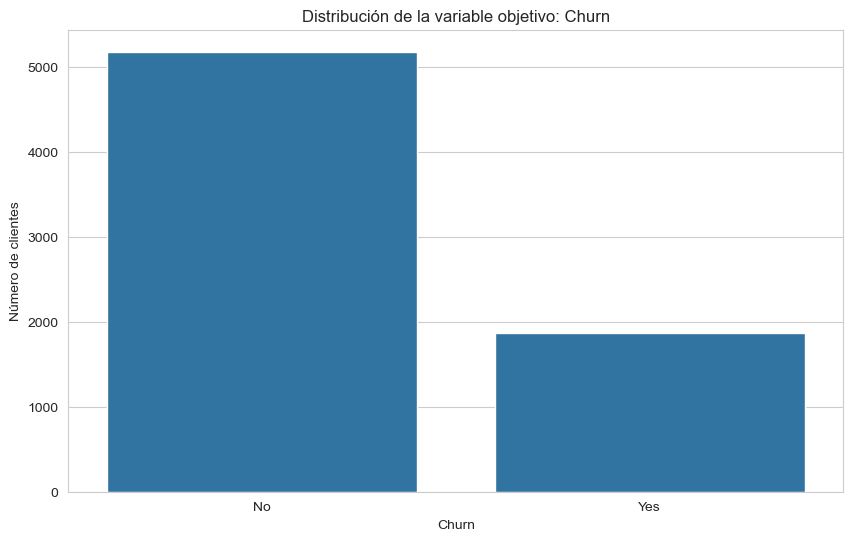

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [16]:
if not df.empty and "Churn" in df.columns:
    sns.countplot(data=df, x="Churn")
    plt.title("Distribución de la variable objetivo: Churn")
    plt.xlabel("Churn")
    plt.ylabel("Número de clientes")
    plt.show()

    print(df["Churn"].value_counts(normalize=True).rename("proportion"))

**Interpretación esperada:**  
Si la clase está desbalanceada, eso puede afectar el desempeño del modelo.  
Por ello, además de accuracy, usaremos métricas como **precision**, **recall**, **F1-score** y **ROC-AUC**.

## 5.2 Variables numéricas

Ahora exploramos variables numéricas como:

- `tenure`
- `MonthlyCharges`
- `TotalCharges`

Esto permite identificar diferencias entre clientes que cancelan y los que no.

In [18]:
numeric_cols = []
if not df.empty:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    print("Columnas numéricas:", numeric_cols)

Columnas numéricas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


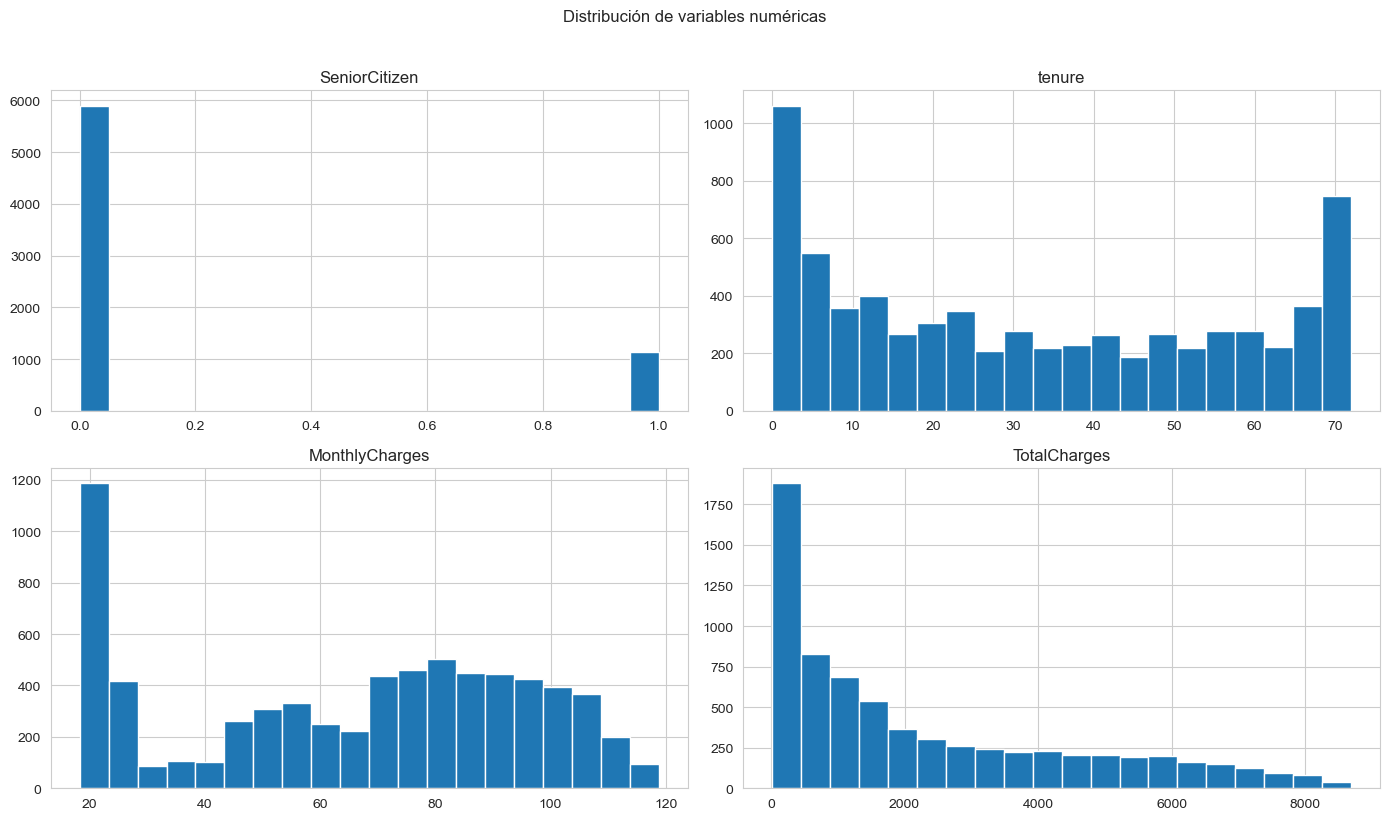

In [20]:
if not df.empty and numeric_cols:
    df[numeric_cols].hist(bins=20, figsize=(14, 8))
    plt.suptitle("Distribución de variables numéricas", y=1.02)
    plt.tight_layout()
    plt.show()

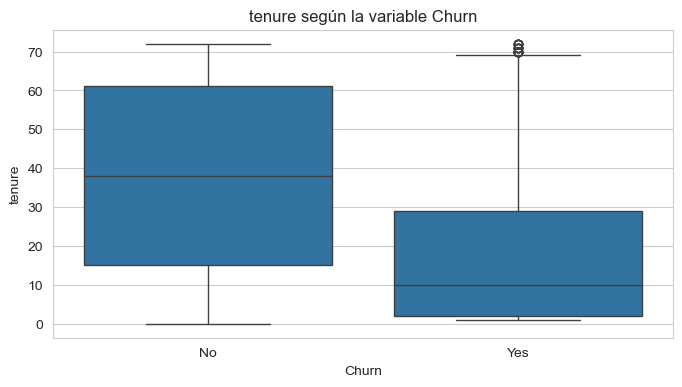

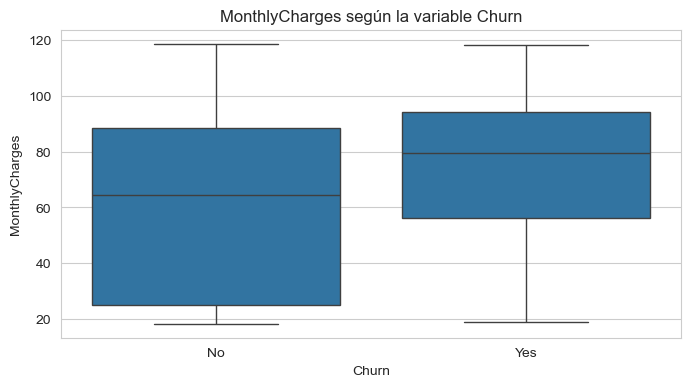

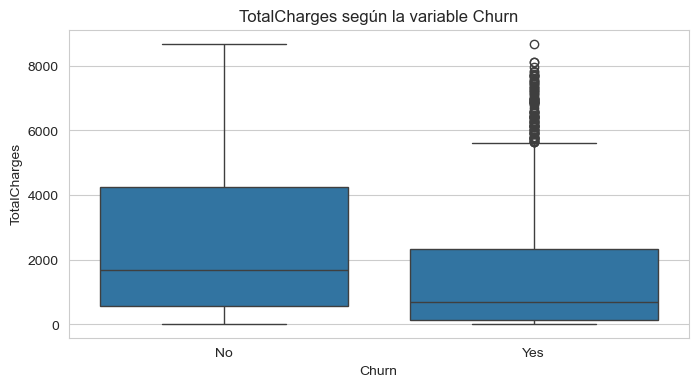

In [21]:
if not df.empty and "Churn" in df.columns:
    for col in [c for c in ["tenure", "MonthlyCharges", "TotalCharges"] if c in df.columns]:
        plt.figure(figsize=(8, 4))
        sns.boxplot(data=df, x="Churn", y=col)
        plt.title(f"{col} según la variable Churn")
        plt.show()

## 5.3 Variables categóricas

Las variables categóricas suelen ser muy importantes en churn.  
Por ejemplo:

- tipo de contrato
- servicio de internet
- método de pago
- si el cliente tiene soporte técnico

In [25]:
if not df.empty:
    categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
    print("Columnas categóricas:")
    print(categorical_cols)

Columnas categóricas:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


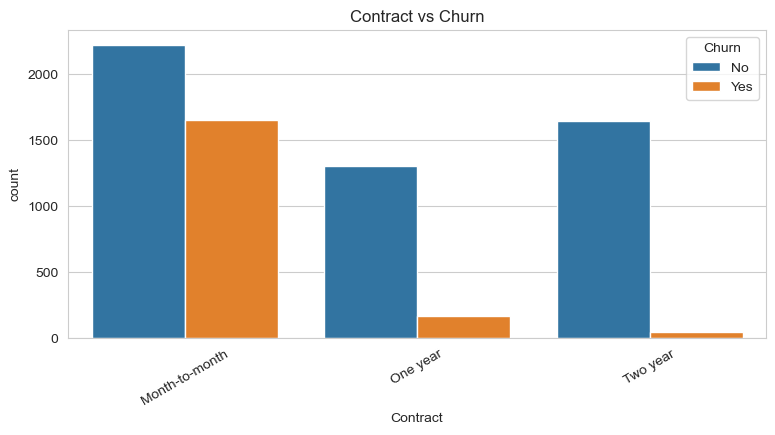

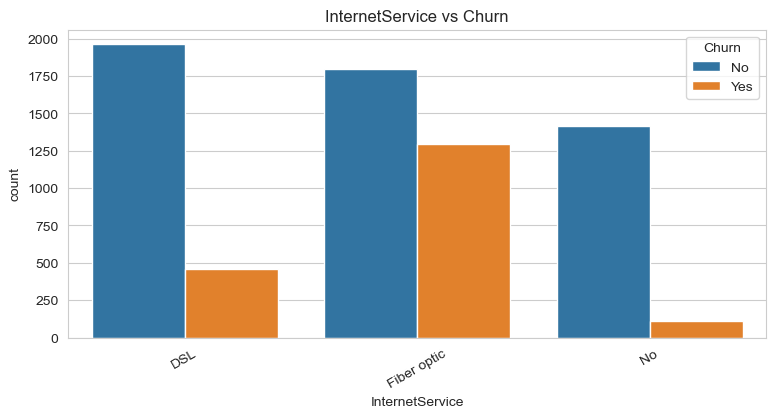

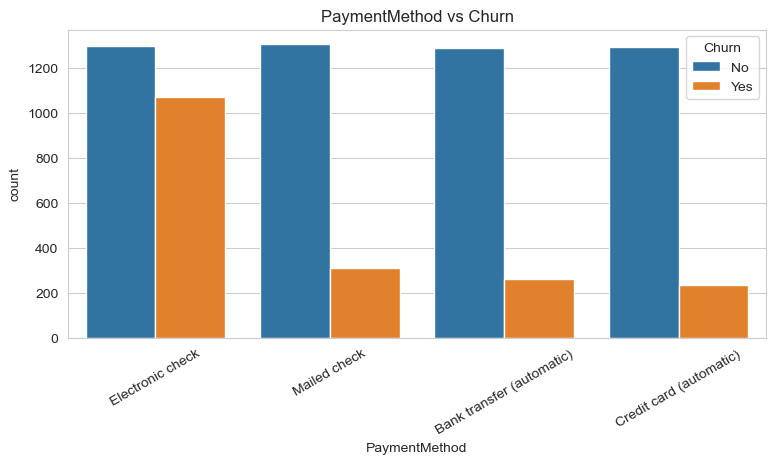

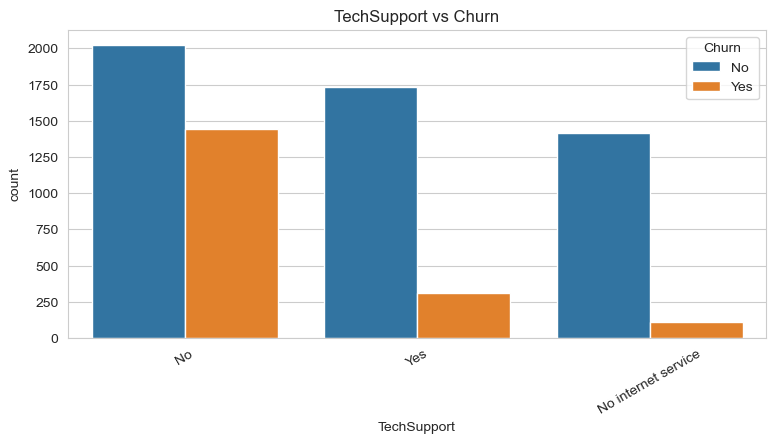

In [27]:
if not df.empty and "Churn" in df.columns:
    candidate_cols = [c for c in ["Contract", "InternetService", "PaymentMethod", "TechSupport"] if c in df.columns]

    for col in candidate_cols:
        plt.figure(figsize=(9, 4))
        sns.countplot(data=df, x=col, hue="Churn")
        plt.title(f"{col} vs Churn")
        plt.xticks(rotation=30)
        plt.show()

## 5.4 Matriz de correlación

La correlación se analiza solo en variables numéricas.  
Esto sirve para detectar relaciones lineales fuertes y entender la estructura del dataset.

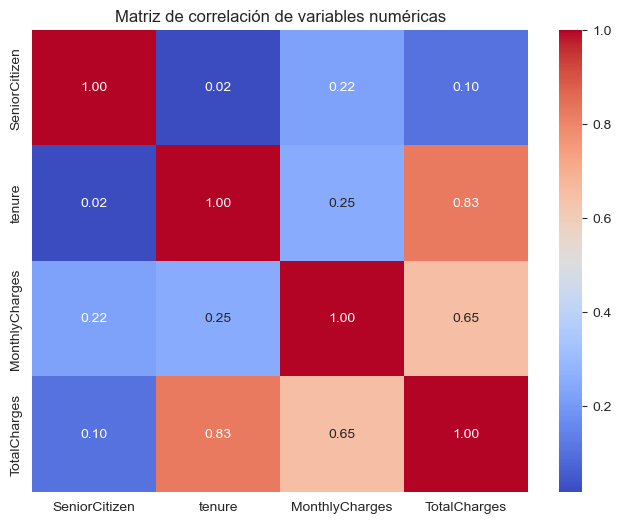

In [29]:
if not df.empty and numeric_cols:
    plt.figure(figsize=(8, 6))
    sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Matriz de correlación de variables numéricas")
    plt.show()

# 6. Preparación de datos para el modelo

Antes de entrenar modelos, debemos preparar los datos correctamente.

En esta etapa:

- separamos variable objetivo y variables predictoras
- convertimos la variable `Churn` a formato binario
- identificamos columnas numéricas y categóricas
- construimos un flujo de preprocesamiento

Usaremos un enfoque profesional con `Pipeline` y `ColumnTransformer`, lo cual facilita la reproducibilidad.

In [31]:
if not df.empty and "Churn" in df.columns:
    model_df = df.copy()

    # Convertir la variable objetivo a binaria
    if model_df["Churn"].dtype == "object":
        model_df["Churn"] = model_df["Churn"].map({"Yes": 1, "No": 0})

    # En algunos datasets existe customerID, que no aporta al modelo
    if "customerID" in model_df.columns:
        model_df = model_df.drop(columns=["customerID"])

    X = model_df.drop(columns=["Churn"])
    y = model_df["Churn"]

    categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
    numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()

    print("Variables predictoras:", X.shape[1])
    print("Variables numéricas:", numeric_features)
    print("Variables categóricas:", categorical_features)

Variables predictoras: 19
Variables numéricas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Variables categóricas: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 6.1 Separación de entrenamiento y prueba

Dividimos los datos en:

- **80% entrenamiento**
- **20% prueba**

Esto permite evaluar el modelo sobre datos no vistos.

In [33]:
if not df.empty and "Churn" in df.columns:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    print("Tamaño de entrenamiento:", X_train.shape)
    print("Tamaño de prueba:", X_test.shape)

Tamaño de entrenamiento: (5634, 19)
Tamaño de prueba: (1409, 19)


## 6.2 Preprocesamiento

Definimos dos transformaciones:

### Variables numéricas
- imputación con la mediana
- escalamiento estándar

### Variables categóricas
- imputación con la categoría más frecuente
- codificación one-hot

Este enfoque es adecuado porque mezcla variables numéricas y categóricas.

In [35]:
if not df.empty and "Churn" in df.columns:
    from sklearn.preprocessing import OneHotEncoder

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ]
    )

    print("Preprocesador listo.")

Preprocesador listo.


# 7. Entrenamiento de modelos

Para que el proyecto final tenga más valor, entrenaremos dos modelos:

1. **Regresión Logística**  
2. **Random Forest**

Esto permite comparar un modelo lineal clásico frente a un modelo basado en árboles.

## 7.1 Modelo 1: Regresión Logística

La regresión logística es un modelo base excelente para problemas de clasificación binaria.  
Es interpretable y funciona bien cuando las relaciones entre variables y objetivo son relativamente lineales.

In [37]:
if not df.empty and "Churn" in df.columns:
    logistic_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ])

    logistic_model.fit(X_train, y_train)

    y_pred_log = logistic_model.predict(X_test)
    y_proba_log = logistic_model.predict_proba(X_test)[:, 1]

    print("Modelo de Regresión Logística entrenado correctamente.")

Modelo de Regresión Logística entrenado correctamente.


## 7.2 Evaluación del modelo de Regresión Logística

In [40]:
if not df.empty and "Churn" in df.columns:
    print("Accuracy:", round(accuracy_score(y_test, y_pred_log), 4))
    print("Precision:", round(precision_score(y_test, y_pred_log), 4))
    print("Recall:", round(recall_score(y_test, y_pred_log), 4))
    print("F1-score:", round(f1_score(y_test, y_pred_log), 4))
    print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_log), 4))

Accuracy: 0.8055
Precision: 0.6572
Recall: 0.5588
F1-score: 0.604
ROC-AUC: 0.8419


In [42]:
if not df.empty and "Churn" in df.columns:
    print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



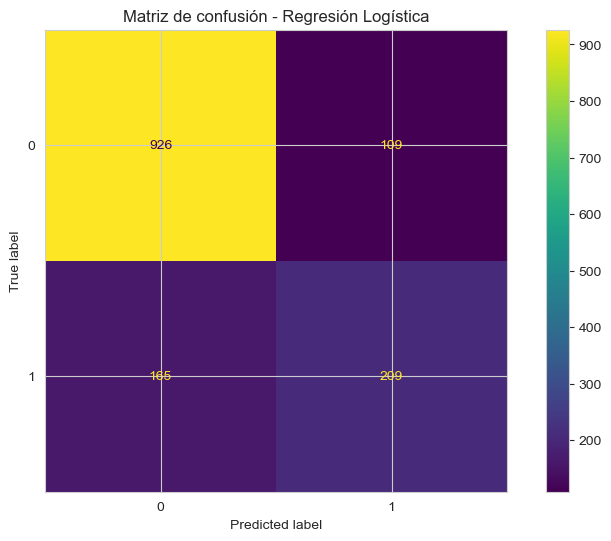

In [44]:
if not df.empty and "Churn" in df.columns:
    cm = confusion_matrix(y_test, y_pred_log)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title("Matriz de confusión - Regresión Logística")
    plt.show()

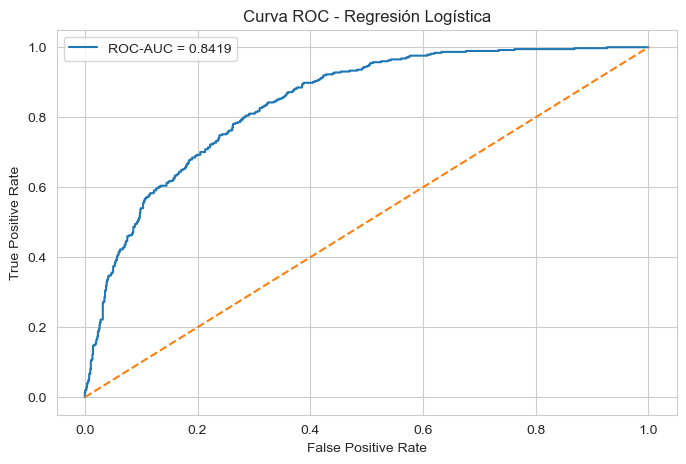

In [46]:
if not df.empty and "Churn" in df.columns:
    fpr, tpr, thresholds = roc_curve(y_test, y_proba_log)

    plt.figure(figsize=(8, 5))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, y_proba_log):.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Curva ROC - Regresión Logística")
    plt.legend()
    plt.show()

## 7.3 Modelo 2: Random Forest

Random Forest es un ensamble de árboles de decisión.  
Suele capturar relaciones no lineales y combinaciones complejas de variables.

In [48]:
if not df.empty and "Churn" in df.columns:
    rf_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            random_state=42,
            class_weight="balanced"
        ))
    ])

    rf_model.fit(X_train, y_train)

    y_pred_rf = rf_model.predict(X_test)
    y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

    print("Modelo Random Forest entrenado correctamente.")

Modelo Random Forest entrenado correctamente.


## 7.4 Evaluación del modelo Random Forest

In [50]:
if not df.empty and "Churn" in df.columns:
    print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
    print("Precision:", round(precision_score(y_test, y_pred_rf), 4))
    print("Recall:", round(recall_score(y_test, y_pred_rf), 4))
    print("F1-score:", round(f1_score(y_test, y_pred_rf), 4))
    print("ROC-AUC:", round(roc_auc_score(y_test, y_proba_rf), 4))

Accuracy: 0.7814
Precision: 0.617
Recall: 0.4652
F1-score: 0.5305
ROC-AUC: 0.8217


In [51]:
if not df.empty and "Churn" in df.columns:
    print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1035
           1       0.62      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



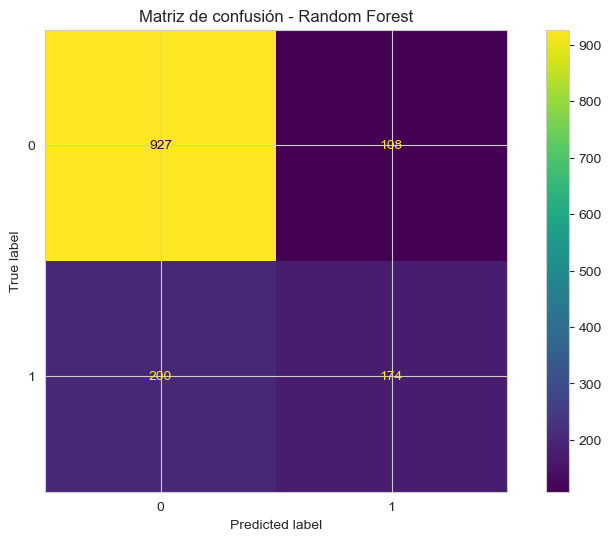

In [55]:
if not df.empty and "Churn" in df.columns:
    cm_rf = confusion_matrix(y_test, y_pred_rf)
    disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
    disp_rf.plot()
    plt.title("Matriz de confusión - Random Forest")
    plt.show()

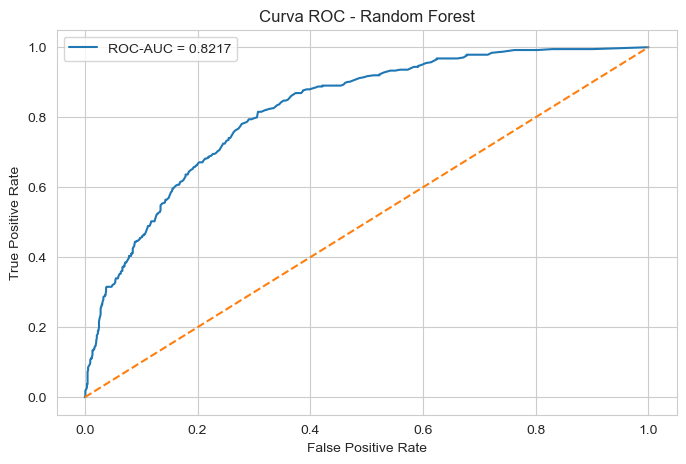

In [57]:
if not df.empty and "Churn" in df.columns:
    fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_proba_rf)

    plt.figure(figsize=(8, 5))
    plt.plot(fpr_rf, tpr_rf, label=f"ROC-AUC = {roc_auc_score(y_test, y_proba_rf):.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Curva ROC - Random Forest")
    plt.legend()
    plt.show()

# 8. Comparación de modelos

En esta sección comparamos ambos modelos usando métricas relevantes.  
Esto ayuda a seleccionar el modelo con mejor desempeño general.

In [81]:
if not df.empty and "Churn" in df.columns:
    comparison = pd.DataFrame({
        "Modelo": ["Regresión Logística", "Random Forest"],
        "Accuracy": [
            accuracy_score(y_test, y_pred_log),
            accuracy_score(y_test, y_pred_rf)
        ],
        "Precision": [
            precision_score(y_test, y_pred_log),
            precision_score(y_test, y_pred_rf)
        ],
        "Recall": [
            recall_score(y_test, y_pred_log),
            recall_score(y_test, y_pred_rf)
        ],
        "F1-score": [
            f1_score(y_test, y_pred_log),
            f1_score(y_test, y_pred_rf)
        ],
        "ROC-AUC": [
            roc_auc_score(y_test, y_proba_log),
            roc_auc_score(y_test, y_proba_rf)
        ]
    })

    print(comparison)

                Modelo  Accuracy  Precision    Recall  F1-score   ROC-AUC
0  Regresión Logística  0.805536   0.657233  0.558824  0.604046  0.841861
1        Random Forest  0.781405   0.617021  0.465241  0.530488  0.821673


**Interpretación sugerida:**  
No siempre el mejor modelo será el de mayor accuracy.  
En churn, normalmente interesa mucho el **recall**, porque detectar clientes que podrían irse puede ser más importante que clasificar correctamente todos los casos.

Por ello, la decisión final del modelo debe alinearse con el objetivo de negocio.

# 9. Importancia de variables (opcional)

En proyectos de ciencia de datos para portafolio, es muy valioso explicar **qué variables influyen más** en la predicción.

Para Random Forest podemos extraer la importancia de variables transformadas.

In [76]:
if not df.empty and "Churn" in df.columns:
    # Obtener nombres de variables después del preprocesamiento
    preprocessor_fitted = rf_model.named_steps["preprocessor"]
    rf_fitted = rf_model.named_steps["classifier"]

    feature_names_num = numeric_features
    feature_names_cat = list(
        preprocessor_fitted.named_transformers_["cat"]
        .named_steps["onehot"]
        .get_feature_names_out(categorical_features)
    )

    all_feature_names = feature_names_num + feature_names_cat

    importances = rf_fitted.feature_importances_

    importance_df = pd.DataFrame({
        "feature": all_feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False)

    importance_df.head(15)

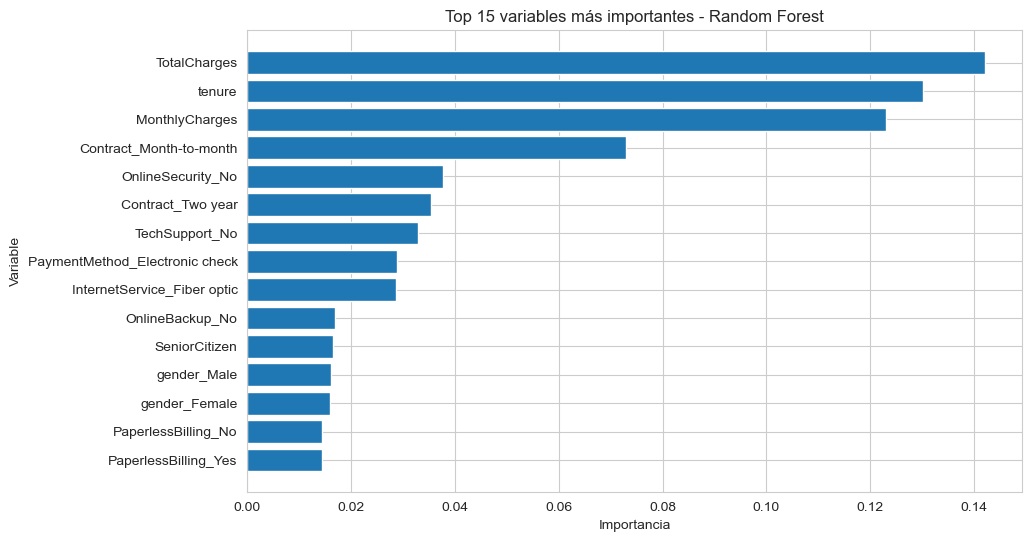

In [78]:
if not df.empty and "Churn" in df.columns:
    top_features = importance_df.head(15).sort_values("importance")

    plt.figure(figsize=(10, 6))
    plt.barh(top_features["feature"], top_features["importance"])
    plt.title("Top 15 variables más importantes - Random Forest")
    plt.xlabel("Importancia")
    plt.ylabel("Variable")
    plt.show()

# 10. Conclusiones

## Hallazgos técnicos

A partir del análisis realizado, se puede concluir que:

- el problema de churn puede abordarse de forma efectiva con modelos de clasificación supervisada
- variables como antigüedad del cliente, cargos mensuales, cargos totales, tipo de contrato y soporte técnico suelen ser relevantes
- el preprocesamiento adecuado de variables categóricas y numéricas mejora la calidad del modelo

## Hallazgos de negocio

Desde una perspectiva de negocio, este proyecto permite:

- identificar clientes con mayor riesgo de abandono
- diseñar campañas de retención
- enfocar esfuerzos comerciales en segmentos vulnerables
- reducir la pérdida de ingresos por cancelación de servicios

## Recomendación

Para un entorno real, se recomienda:

1. probar más modelos como XGBoost o LightGBM  
2. ajustar hiperparámetros  
3. tratar desbalance de clases más a fondo  
4. monitorear el modelo en producción  
5. crear tableros
---

# 11. Siguientes pasos para GitHub

recomiendo agregar:

- `README.md`
- `requirements.txt`
- una breve explicación de negocio en la portada del repositorio

---

## requirements.txt

```txt

```

---

## Cierre

Este notebook puede utilizarse como **proyecto final de ciencia de datos**, como parte de un portafolio profesional y como evidencia de habilidades en:

- análisis exploratorio de datos
- limpieza y transformación de datos
- machine learning
- interpretación de resultados
- comunicación de hallazgos